In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from datasets import Dataset

In [10]:
tokenizers = ("SentencePieceBPE")
vocab_sizes = [(2 ** 8) * (2 ** i) for i in range(2, 10, 2)]

data = {}
for v in vocab_sizes:
    path = Path(f"./output/datasets/tokenized/{v}")
    if not path.exists():
        continue
    print(f"Loading {v}")
    tokenized_dataset = Dataset.load_from_disk(path, keep_in_memory=True)
    data[v] = [len(d["input_ids"]) for d in tokenized_dataset]

Loading 256
Loading 512
Loading 1024
Loading 2048
Loading 4096
Loading 8192
Loading 16384
Loading 32768
Loading 65536
Loading 131072
Loading 262144
Loading 524288
Loading 1048576


In [12]:
import json

with open("sequence-lengths.json", "w") as handle:
    json.dump(data, handle, indent=4)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fc1969e5cf0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fc1969e6230>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fc1969e5a50>,
 'medians': [<matplotlib.lines.Line2D at 0x7fc1969e6770>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fc1969e6a10>,
 'means': []}

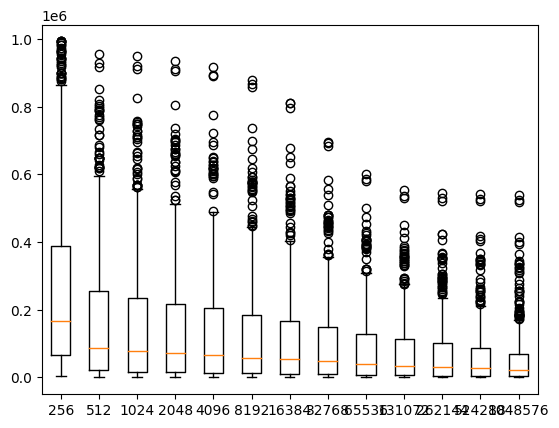

In [13]:
plt.boxplot(data.values(), labels=data.keys())

In [65]:
import matplotlib.pyplot as plt
import numpy as np

root = Path("/home/lk3591/Documents/code/RawByteClf/exploreSequenceLengths")

gpus = ["armitage",]
batch_sizes = [1, 2, 4, 8]
pad_to_multiples = [1024,]

COLORS = ["red", "green", "blue",]

data_batch = {}

for g in gpus:
    for i, b in zip(batch_sizes, (1,2,4,8)):
        for p in pad_to_multiples:
            path = root / g / f"{b}_{p}.csv"
            data_batch[i] = pd.read_csv(path).to_dict('records')
            for r in data_batch[i]:
                r["name"] = r["name"].replace("ForMaskedLM", "")
            print(data_batch[i])

[{'name': 'Longformer', 'params': 87121416, 'max_length': 100352}, {'name': 'BigBird', 'params': 60381192, 'max_length': 67584}, {'name': 'FNet', 'params': 178148616, 'max_length': 223232}, {'name': 'Nystromformer', 'params': 15752724, 'max_length': 10240}, {'name': 'Reformer', 'params': 14458632, 'max_length': 119808}, {'name': 'SqueezeBert', 'params': 11474952, 'max_length': 10240}, {'name': 'Yoso', 'params': 17324040, 'max_length': 12288}]
[{'name': 'Longformer', 'params': 83190000, 'max_length': 95232}, {'name': 'BigBird', 'params': 58810000, 'max_length': 65536}, {'name': 'FNet', 'params': 157700000, 'max_length': 196608}, {'name': 'Nystromformer', 'params': 14966292, 'max_length': 9216}, {'name': 'Reformer', 'params': 14458632, 'max_length': 119808}, {'name': 'SqueezeBert', 'params': 10688520, 'max_length': 9216}, {'name': 'Yoso', 'params': 16537608, 'max_length': 11264}]
[{'name': 'Longformer', 'params': 43081224, 'max_length': 43008}, {'name': 'BigBird', 'params': 33642504, 'ma

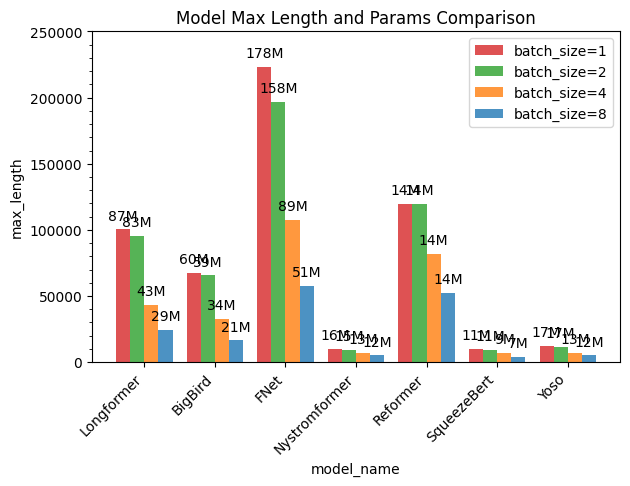

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have data_batch[1], data_batch[2], data_batch[4], and data_batch[8] defined

# Extracting data for plotting
names, params_batch_1, max_lengths_batch_1 = zip(*[(entry["name"], entry["params"], entry["max_length"]) for entry in data_batch[1]])
params_batch_2, max_lengths_batch_2 = zip(*[(entry["params"], entry["max_length"]) for entry in data_batch[2]])
params_batch_4, max_lengths_batch_4 = zip(*[(entry["params"], entry["max_length"]) for entry in data_batch[4]])
params_batch_8, max_lengths_batch_8 = zip(*[(entry["params"], entry["max_length"]) for entry in data_batch[8]])

# Set up positions for each group of bars
bar_width = 0.2
index = np.arange(len(names))

# Plotting
fig, ax1 = plt.subplots()

# Bar plots for max_length
ax1.bar(index - 1.5 * bar_width, max_lengths_batch_1, bar_width, label='batch_size=1', alpha=0.8, color='tab:red')
ax1.bar(index - 0.5 * bar_width, max_lengths_batch_2, bar_width, label='batch_size=2', alpha=0.8, color='tab:green')
ax1.bar(index + 0.5 * bar_width, max_lengths_batch_4, bar_width, label='batch_size=4', alpha=0.8, color='tab:orange')
ax1.bar(index + 1.5 * bar_width, max_lengths_batch_8, bar_width, label='batch_size=8', alpha=0.8, color='tab:blue')

# Annotating with params values on top of max_length bars
for i, value in enumerate(params_batch_1):
    ax1.text(index[i] - 1.5 * bar_width, max_lengths_batch_1[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

for i, value in enumerate(params_batch_2):
    ax1.text(index[i] - 0.5 * bar_width, max_lengths_batch_2[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

for i, value in enumerate(params_batch_4):
    ax1.text(index[i] + 0.5 * bar_width, max_lengths_batch_4[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

for i, value in enumerate(params_batch_8):
    ax1.text(index[i] + 1.5 * bar_width, max_lengths_batch_8[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

ax1.set_xlabel('model_name', color='black')
ax1.set_ylabel('max_length', color='black')
ax1.set_xticks(index)
ax1.set_xticklabels(names, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='black')

ax1.set_yticks(np.arange(0, 250001, 10000), minor=True)

fig.tight_layout()
plt.title('Model Max Length and Params Comparison')
plt.legend()
plt.show()

[{'name': 'Longformer', 'params': 238116360, 'max_length': 296960}, {'name': 'BigBird', 'params': 98916360, 'max_length': 117760}, {'name': 'Nystromformer', 'params': 18898452, 'max_length': 14336}, {'name': 'Reformer', 'params': 14552328, 'max_length': 219136}, {'name': 'SqueezeBert', 'params': 14620680, 'max_length': 14336}]
[{'name': 'Longformer', 'params': 116219400, 'max_length': 138240}, {'name': 'BigBird', 'params': 52516872, 'max_length': 57344}, {'name': 'Nystromformer', 'params': 14966292, 'max_length': 9216}, {'name': 'Reformer', 'params': 14492424, 'max_length': 148480}, {'name': 'SqueezeBert', 'params': 10688520, 'max_length': 9216}]
[{'name': 'Longformer', 'params': 64314888, 'max_length': 70656}, {'name': 'BigBird', 'params': 30496776, 'max_length': 28672}, {'name': 'Nystromformer', 'params': 13393428, 'max_length': 7168}, {'name': 'Reformer', 'params': 14418696, 'max_length': 87040}, {'name': 'SqueezeBert', 'params': 9115656, 'max_length': 7168}]
[{'name': 'Longformer',

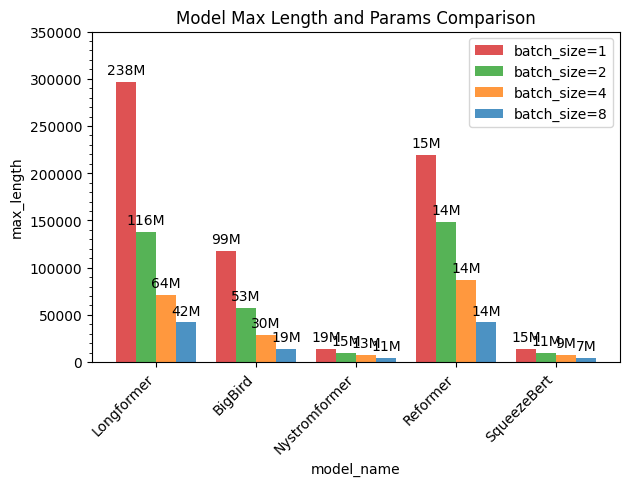

In [71]:
import matplotlib.pyplot as plt
import numpy as np

root = Path("/home/lk3591/Documents/code/RawByteClf/exploreSequenceLengths")

gpus = ["rc",]
batch_sizes = [1, 2, 4, 8]
pad_to_multiples = [1024,]

COLORS = ["red", "green", "blue",]

data_batch = {}

for g in gpus:
    for i, b in zip(batch_sizes, (1,2,4,8)):
        for p in pad_to_multiples:
            path = root / g / f"{b}_{p}.csv"
            data_batch[i] = pd.read_csv(path).to_dict('records')
            for r in data_batch[i]:
                r["name"] = r["name"].replace("ForMaskedLM", "")
            print(data_batch[i])



import matplotlib.pyplot as plt
import numpy as np

# Assuming you have data_batch[1], data_batch[2], data_batch[4], and data_batch[8] defined

# Extracting data for plotting
names, params_batch_1, max_lengths_batch_1 = zip(*[(entry["name"], entry["params"], entry["max_length"]) for entry in data_batch[1]])
params_batch_2, max_lengths_batch_2 = zip(*[(entry["params"], entry["max_length"]) for entry in data_batch[2]])
params_batch_4, max_lengths_batch_4 = zip(*[(entry["params"], entry["max_length"]) for entry in data_batch[4]])
params_batch_8, max_lengths_batch_8 = zip(*[(entry["params"], entry["max_length"]) for entry in data_batch[8]])

# Set up positions for each group of bars
bar_width = 0.2
index = np.arange(len(names))

# Plotting
fig, ax1 = plt.subplots()

# Bar plots for max_length
ax1.bar(index - 1.5 * bar_width, max_lengths_batch_1, bar_width, label='batch_size=1', alpha=0.8, color='tab:red')
ax1.bar(index - 0.5 * bar_width, max_lengths_batch_2, bar_width, label='batch_size=2', alpha=0.8, color='tab:green')
ax1.bar(index + 0.5 * bar_width, max_lengths_batch_4, bar_width, label='batch_size=4', alpha=0.8, color='tab:orange')
ax1.bar(index + 1.5 * bar_width, max_lengths_batch_8, bar_width, label='batch_size=8', alpha=0.8, color='tab:blue')

# Annotating with params values on top of max_length bars
for i, value in enumerate(params_batch_1):
    ax1.text(index[i] - 1.5 * bar_width, max_lengths_batch_1[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

for i, value in enumerate(params_batch_2):
    ax1.text(index[i] - 0.5 * bar_width, max_lengths_batch_2[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

for i, value in enumerate(params_batch_4):
    ax1.text(index[i] + 0.5 * bar_width, max_lengths_batch_4[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

for i, value in enumerate(params_batch_8):
    ax1.text(index[i] + 1.5 * bar_width, max_lengths_batch_8[i] + 5000, f'{value / 1e6:.0f}M', ha='center', va='bottom', color='black')

ax1.set_xlabel('model_name', color='black')
ax1.set_ylabel('max_length', color='black')
ax1.set_xticks(index)
ax1.set_xticklabels(names, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='black')

ax1.set_yticks(np.arange(0, 350001, 10000), minor=True)

fig.tight_layout()
plt.title('Model Max Length and Params Comparison')
plt.legend()
plt.show()

In [63]:
from collections import Counter
import os
from pprint import pprint
import sys

os.chdir("/home/lk3591/Documents/code/RawByteClf")

from datasets import Dataset, DatasetDict, concatenate_datasets
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.datasets import make_classification
from tqdm import tqdm

from src.data.loaders import get_bodmas_dataset


In [22]:
dataset, distribution = get_bodmas_dataset()
dataset = concatenate_datasets([dataset[s] for s in dataset])
dataset

Dataset({
    features: ['name', 'bytes', 'size', 'length', 'labels'],
    num_rows: 57293
})

In [24]:
id2label = {i: n for i, n in enumerate(dataset.features["labels"].names)}
label2id = {n: i for i, n in id2label.items()}
one_labels = {c for c in distribution if distribution[c] == 1}
one_ids = {label2id[c] for c in one_labels}

In [26]:
dataset = dataset.filter(lambda exs: [e not in one_ids for e in exs["labels"]], batched=True)
dataset

Filter:   0%|          | 0/57095 [00:00<?, ? examples/s]

Dataset({
    features: ['name', 'bytes', 'size', 'length', 'labels'],
    num_rows: 57095
})

In [27]:
def get_dist(dat: Dataset) -> Counter:
	return Counter([id2label[i] for d in dat.select_columns("labels").iter(1024) for i in d["labels"]])

In [31]:
c_0 = get_dist(dataset.train_test_split(0.05)["test"])
len(c_0), c_0.most_common(4), c_0.most_common()[-4:]

(187,
 [('wacatac', 247), ('sfone', 211), ('upatre', 190), ('wabot', 177)],
 [('wanna', 1), ('imestartup', 1), ('danabot', 1), ('pornoasset', 1)])

In [32]:
c_1 = get_dist(dataset.train_test_split(0.05, stratify_by_column="labels")["test"])
len(c_1), c_1.most_common(4), c_1.most_common()[-4:]

(203,
 [('sfone', 237), ('wacatac', 235), ('upatre', 195), ('wabot', 184)],
 [('neconyd', 1), ('lmir', 1), ('magania', 1), ('gamarue', 1)])

In [46]:
X, y = make_classification(
    n_samples=len(dataset),
    n_features=20,
    n_informative=16,
    n_classes=len([c for c, n in distribution.items() if n > 1]),
    weights=[1 / n for n in distribution.values() if n > 1],
    random_state=42,
)

array([129, 192,  68, ..., 112,  80,  98])

In [ ]:
def tr_vl_ts_split(dataset: Dataset, vl_size: float, ts_size: float) -> DatasetDict:
    dataset = dataset.train_test_split(test_size=ts_size)
    dataset["ts"] = dataset.pop("test")
    d = dataset.pop("train").train_test_split(test_size=vl_size / (1 - ts_size))
    dataset["tr"] = d.pop("train")
    dataset["vl"] = d.pop("test")
    return dataset

In [ ]:
def tr_vl_ts_split(
    dataset: Dataset,
    vl_size: float,
    ts_size: float,
    verbose: bool = False,
) -> DatasetDict:

    y = np.array(dataset["labels"])

    i = 0
    j = 0

    while True:
        i += 1
        sss = StratifiedShuffleSplit(1, test_size=ts_size)
        tr_vl_idx, ts_idx = next(sss.split(np.zeros(len(y)), y))

        tr_vl_values, tr_vl_counts = np.unique(y[tr_vl_idx], return_counts=True)
        ts_values = np.unique(y[ts_idx])
        if np.any(tr_vl_counts == 1):
            if verbose:
                print("tr_vl has uniques.")
            continue
        if len(tr_vl_values) != len(ts_values) or not np.all(tr_vl_values == ts_values):
            if verbose:
                print("tr_vl or ts missing values.")
            continue

        while True:
            j += 1
            sss = StratifiedShuffleSplit(1, test_size=vl_size / (1 - ts_size))
            tr_idx, vl_idx = next(sss.split(np.zeros(len(tr_vl_idx)), y[tr_vl_idx]))
            tr_values = np.unique(y[tr_vl_idx][tr_idx])
            vl_values = np.unique(y[tr_vl_idx][vl_idx])
            if len(tr_values) == len(tr_values) and np.all(np.equal(tr_values, vl_values)):
                break
            if verbose:
                print("tr or vl missing values.")

        tr_idx = [tr_vl_idx][tr_idx]
        vl_idx = [tr_vl_idx][vl_idx]
        ts_idx = ts_idx

        assert np.intersect1d(tr_idx, vl_idx).size == 0, "tr and vl overlap"
        assert np.intersect1d(tr_idx, ts_idx).size == 0, "tr and ts overlap"
        assert np.intersect1d(vl_idx, ts_idx).size == 0, "vl and ts overlap"

        print(f"{i} cycles to construct the ts split. {j} cycles to construct the vl split.")

        return {
            "tr": dataset.select(tr_vl_idx[tr_idx]),
            "vl": dataset.select(tr_vl_idx[vl_idx]),
            "ts": dataset.select(ts_idx),
        }


tr_vl_ts_split(dataset, 0.05, 0.05, True)

In [67]:
def tr_vl_ts_split(
    dataset: Dataset,
    vl_size: float,
    ts_size: float,
    verbose: bool = False,
) -> DatasetDict:

    y = np.array(dataset["labels"])

    i = 0
    j = 0

    while True:
        i += 1
        sss = StratifiedShuffleSplit(1, test_size=ts_size)
        tr_vl_idx, ts_idx = next(sss.split(np.zeros(len(y)), y))

        tr_vl_values, tr_vl_counts = np.unique(y[tr_vl_idx], return_counts=True)
        ts_values = np.unique(y[ts_idx])
        if np.any(tr_vl_counts == 1):
            if verbose:
                print("tr_vl has uniques.")
            continue
        if len(tr_vl_values) != len(ts_values) or not np.all(tr_vl_values == ts_values):
            if verbose:
                print("tr_vl or ts missing values.")
            continue

        while True:
            j += 1
            sss = StratifiedShuffleSplit(1, test_size=vl_size / (1 - ts_size))
            tr_idx, vl_idx = next(sss.split(np.zeros(len(tr_vl_idx)), y[tr_vl_idx]))
            tr_values = np.unique(y[tr_vl_idx][tr_idx])
            vl_values = np.unique(y[tr_vl_idx][vl_idx])
            if len(tr_values) == len(tr_values) and np.all(np.equal(tr_values, vl_values)):
                break
            if verbose:
                print("tr or vl missing values.")

        tr_idx = [tr_vl_idx][tr_idx]
        vl_idx = [tr_vl_idx][vl_idx]
        ts_idx = ts_idx

        assert np.intersect1d(tr_idx, vl_idx).size == 0, "tr and vl overlap"
        assert np.intersect1d(tr_idx, ts_idx).size == 0, "tr and ts overlap"
        assert np.intersect1d(vl_idx, ts_idx).size == 0, "vl and ts overlap"

        print(f"{i} cycles to construct the ts split. {j} cycles to construct the vl split.")

        return {
            "tr": dataset.select(tr_vl_idx[tr_idx]),
            "vl": dataset.select(tr_vl_idx[vl_idx]),
            "ts": dataset.select(ts_idx),
        }


tr_vl_ts_split(dataset, 0.05, 0.05, True)

len(np.unique(y))=384
len(np.unique(y_train))=384
len(np.unique(y_test))=203


(None, None, None)